Loading datasets...
Filtering VIIRS data for 2024-07...
Generating Plot 1: Infrastructure...
Generating Plot 2: Satellite Detections...
Generating Plot 3: Composite Overlay...
Plot saved to /Users/vineeth/work/projects/summer26-permian-flaring/visualizations/spatial_layers_comparison.png


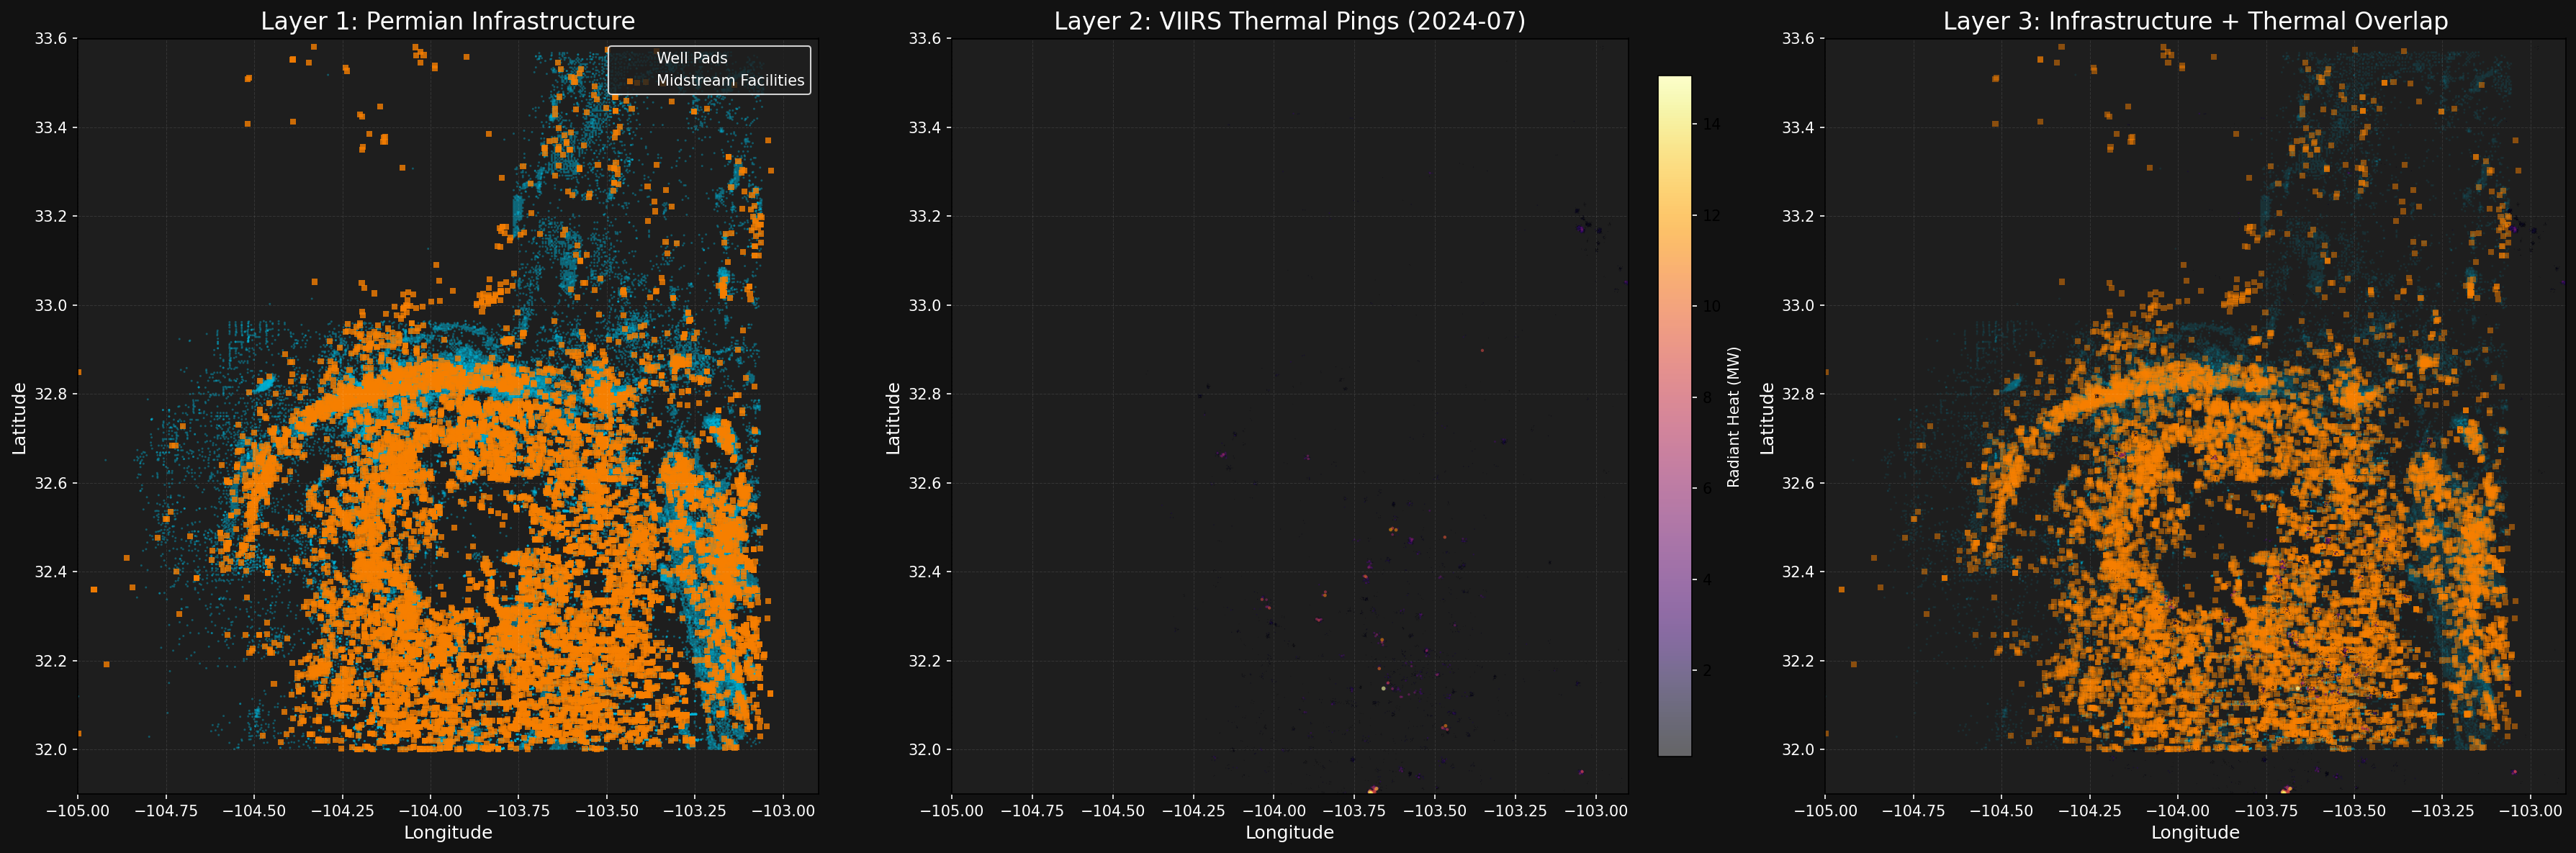

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
project_root = os.path.expanduser('~/work/projects/summer26-permian-flaring')
interim_dir = os.path.join(project_root, 'data/interim/new-mexico')
raw_dir = os.path.join(project_root, 'data/raw/new-mexico/viirs')

print("Loading datasets...")
# Load Infrastructure
df_wells = pd.read_csv(os.path.join(interim_dir, 'nm_wells_spatial.csv'))
df_facilities = pd.read_csv(os.path.join(interim_dir, 'nm_facilities.csv'))

# Load VIIRS and convert the date column
df_viirs = pd.read_csv(os.path.join(raw_dir, 'nm_viirs_vnf_2021_2026.csv'), parse_dates=['Date_Mscan'])

# ==========================================
# 2. FILTER VIIRS FOR A SINGLE MONTH
# ==========================================
# Let's isolate July 2024 as our sample month
target_year = 2024
target_month = 7

print(f"Filtering VIIRS data for {target_year}-{target_month:02d}...")
df_viirs_month = df_viirs[
    (df_viirs['Date_Mscan'].dt.year == target_year) & 
    (df_viirs['Date_Mscan'].dt.month == target_month)
].copy()

# Permian Bounding Box
LAT_MIN, LAT_MAX = 31.9, 33.6
LON_MIN, LON_MAX = -105.0, -102.9

# ==========================================
# 3. PLOT INITIALIZATION
# ==========================================
# Create a 1x3 grid of plots
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=150)
fig.patch.set_facecolor('#121212') # Dark background for high contrast

for ax in axes:
    ax.set_facecolor('#1e1e1e')
    ax.set_xlim([LON_MIN, LON_MAX])
    ax.set_ylim([LAT_MIN, LAT_MAX])
    ax.tick_params(axis='both', colors='white')
    ax.grid(color='white', alpha=0.1, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Longitude', color='white', fontsize=12)
    ax.set_ylabel('Latitude', color='white', fontsize=12)

# ==========================================
# 4. PLOT 1: INFRASTRUCTURE ONLY
# ==========================================
print("Generating Plot 1: Infrastructure...")
axes[0].set_title('Layer 1: Permian Infrastructure', color='white', fontsize=16)

# Plot Wells as tiny blue dots
axes[0].scatter(df_wells['Longitude'], df_wells['Latitude'], 
                s=2, c='#00b4d8', alpha=0.4, label='Well Pads', edgecolors='none')

# Plot Facilities as slightly larger orange squares to differentiate them
axes[0].scatter(df_facilities['longitude'], df_facilities['latitude'], 
                s=15, c='#f77f00', marker='s', alpha=0.8, label='Midstream Facilities', edgecolors='none')

axes[0].legend(loc='upper right', facecolor='#1e1e1e', edgecolor='white', labelcolor='white')

# ==========================================
# 5. PLOT 2: SATELLITE THERMAL DETECTIONS ONLY
# ==========================================
print("Generating Plot 2: Satellite Detections...")
axes[1].set_title(f'Layer 2: VIIRS Thermal Pings ({target_year}-{target_month:02d})', color='white', fontsize=16)

# Plot flares. Size and color intensity scale with Radiant Heat (RH)
# We sort by RH so the hottest flares are plotted on top
df_viirs_month = df_viirs_month.sort_values(by='RH', ascending=True)

scatter_viirs = axes[1].scatter(
    df_viirs_month['Lon_GMTCO'], 
    df_viirs_month['Lat_GMTCO'], 
    s=df_viirs_month['RH'] / 2, # Scale down the marker size
    c=df_viirs_month['RH'], 
    cmap='inferno', 
    alpha=0.6,
    edgecolors='none'
)

# Add a colorbar
cb = fig.colorbar(scatter_viirs, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label('Radiant Heat (MW)', color='white')
cb.ax.yaxis.set_tick_params(color='white')

# ==========================================
# 6. PLOT 3: THE COMPOSITE OVERLAY
# ==========================================
print("Generating Plot 3: Composite Overlay...")
axes[2].set_title('Layer 3: Infrastructure + Thermal Overlap', color='white', fontsize=16)

# 1. Base Layer: Wells
axes[2].scatter(df_wells['Longitude'], df_wells['Latitude'], 
                s=2, c='#00b4d8', alpha=0.1, edgecolors='none') # Extremely transparent

# 2. Mid Layer: Facilities
axes[2].scatter(df_facilities['longitude'], df_facilities['latitude'], 
                s=15, c='#f77f00', marker='s', alpha=0.5, edgecolors='none')

# 3. Top Layer: Fire
axes[2].scatter(
    df_viirs_month['Lon_GMTCO'], 
    df_viirs_month['Lat_GMTCO'], 
    s=df_viirs_month['RH'] / 2,
    c=df_viirs_month['RH'], 
    cmap='inferno', 
    alpha=0.7,
    edgecolors='none'
)

# ==========================================
# 7. FINALIZE AND SAVE
# ==========================================
plt.tight_layout()
os.makedirs(os.path.join(project_root, 'visualizations'), exist_ok=True)
output_path = os.path.join(project_root, 'visualizations/spatial_layers_comparison.png')
plt.savefig(output_path, facecolor=fig.get_facecolor(), edgecolor='none')
print(f"Plot saved to {output_path}")

plt.show()

Loading datasets...
Filtering VIIRS data for 2021 through 2025...
Spatially aggregating 5-year thermal footprint by unique coordinates...
Generating Plot 1: Infrastructure...
Generating Plot 2: Aggregated Satellite Detections...
Generating Plot 3: Composite Overlay...
Aggregated figure successfully saved to /Users/vineeth/work/projects/summer26-permian-flaring/visualizations/spatial_layers_2021_2025.png


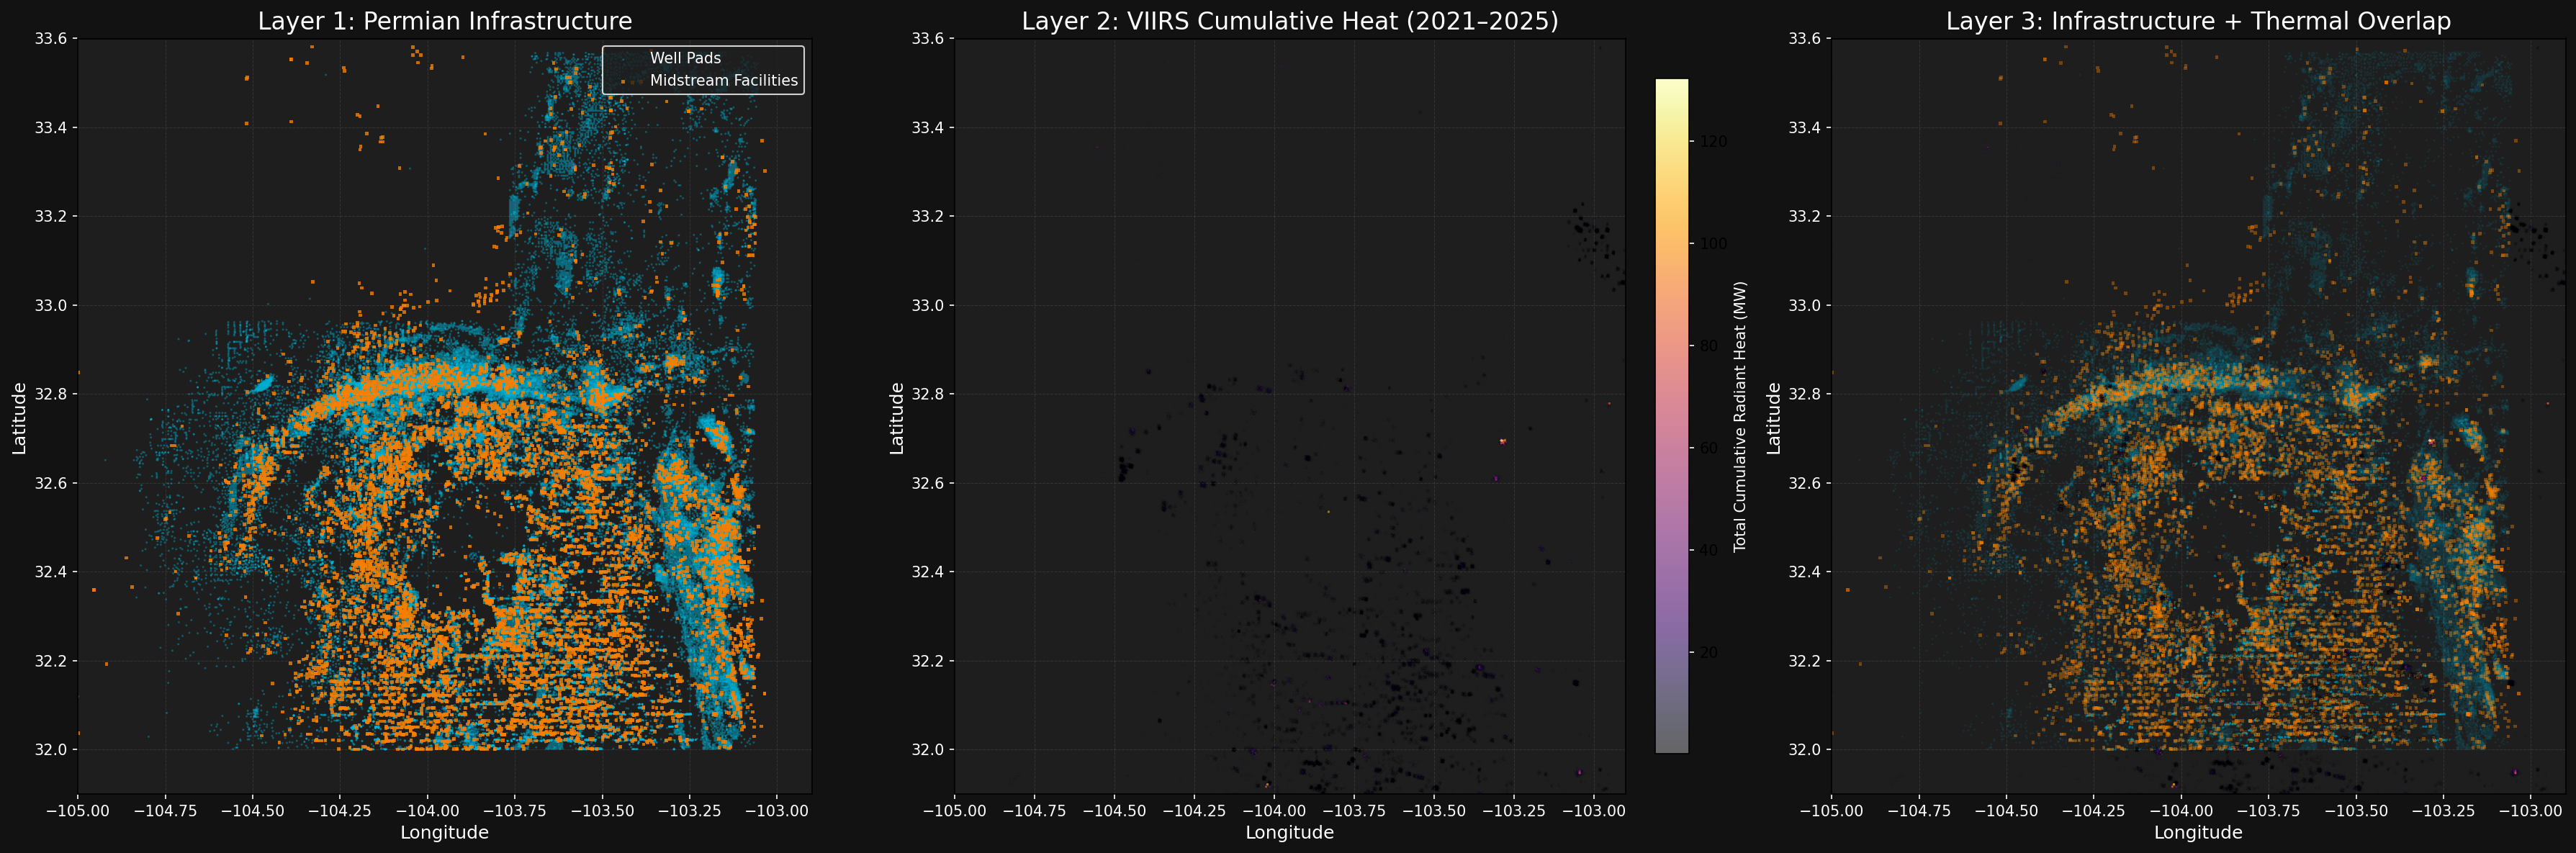

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
project_root = os.path.expanduser('~/work/projects/summer26-permian-flaring')
interim_dir = os.path.join(project_root, 'data/interim/new-mexico')
raw_dir = os.path.join(project_root, 'data/raw/new-mexico/viirs')

print("Loading datasets...")
# Load infrastructure layers
df_wells = pd.read_csv(os.path.join(interim_dir, 'nm_wells_spatial.csv'))
df_facilities = pd.read_csv(os.path.join(interim_dir, 'nm_facilities.csv'))

# Load comprehensive VIIRS dataset
df_viirs = pd.read_csv(os.path.join(raw_dir, 'nm_viirs_vnf_2021_2026.csv'), parse_dates=['Date_Mscan'])

# ==========================================
# 2. FILTER & AGGREGATE VIIRS (2021 - 2025)
# ==========================================
print("Filtering VIIRS data for 2021 through 2025...")
df_viirs_filtered = df_viirs[
    (df_viirs['Date_Mscan'].dt.year >= 2021) & 
    (df_viirs['Date_Mscan'].dt.year <= 2025)
].copy()

print("Spatially aggregating 5-year thermal footprint by unique coordinates...")
# Group by exact coordinates to sum cumulative Radiant Heat (RH) over the timeframe
df_viirs_agg = df_viirs_filtered.groupby(['Lat_GMTCO', 'Lon_GMTCO'])['RH'].sum().reset_index()

# Permian Bounding Box
LAT_MIN, LAT_MAX = 31.9, 33.6
LON_MIN, LON_MAX = -105.0, -102.9

# ==========================================
# 3. PLOT INITIALIZATION
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(24, 8), dpi=150)
fig.patch.set_facecolor('#121212') # Deep dark aesthetic

for ax in axes:
    ax.set_facecolor('#1e1e1e')
    ax.set_xlim([LON_MIN, LON_MAX])
    ax.set_ylim([LAT_MIN, LAT_MAX])
    ax.tick_params(axis='both', colors='white')
    ax.grid(color='white', alpha=0.1, linestyle='--', linewidth=0.5)
    ax.set_xlabel('Longitude', color='white', fontsize=12)
    ax.set_ylabel('Latitude', color='white', fontsize=12)

# ==========================================
# 4. PLOT 1: INFRASTRUCTURE ONLY
# ==========================================
print("Generating Plot 1: Infrastructure...")
axes[0].set_title('Layer 1: Permian Infrastructure', color='white', fontsize=16)

# Well Pads (Using master case-sensitive column names)
axes[0].scatter(df_wells['Longitude'], df_wells['Latitude'], 
                s=2, c='#00b4d8', alpha=0.4, label='Well Pads', edgecolors='none')

# Midstream Facilities (Reduced marker size from 15 to 5)
axes[0].scatter(df_facilities['longitude'], df_facilities['latitude'], 
                s=5, c='#f77f00', marker='s', alpha=0.8, label='Midstream Facilities', edgecolors='none')

axes[0].legend(loc='upper right', facecolor='#1e1e1e', edgecolor='white', labelcolor='white')

# ==========================================
# 5. PLOT 2: CUMULATIVE SATELLITE DETECTIONS
# ==========================================
print("Generating Plot 2: Aggregated Satellite Detections...")
axes[1].set_title('Layer 2: VIIRS Cumulative Heat (2021–2025)', color='white', fontsize=16)

# Sort by cumulative RH so high-volume areas render on top
df_viirs_agg = df_viirs_agg.sort_values(by='RH', ascending=True)

# Scaled down the marker sizes slightly to account for high multi-year sums
scatter_viirs = axes[1].scatter(
    df_viirs_agg['Lon_GMTCO'], 
    df_viirs_agg['Lat_GMTCO'], 
    s=df_viirs_agg['RH'] / 40, 
    c=df_viirs_agg['RH'], 
    cmap='inferno', 
    alpha=0.6,
    edgecolors='none'
)

cb = fig.colorbar(scatter_viirs, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_label('Total Cumulative Radiant Heat (MW)', color='white')
cb.ax.yaxis.set_tick_params(color='white')

# ==========================================
# 6. PLOT 3: THE COMPOSITE OVERLAY
# ==========================================
print("Generating Plot 3: Composite Overlay...")
axes[2].set_title('Layer 3: Infrastructure + Thermal Overlap', color='white', fontsize=16)

# Base Layer: Well Pads (High transparency to serve as spatial background context)
axes[2].scatter(df_wells['Longitude'], df_wells['Latitude'], 
                s=2, c='#00b4d8', alpha=0.1, edgecolors='none')

# Mid Layer: Midstream Facilities (Size 5 marker)
axes[2].scatter(df_facilities['longitude'], df_facilities['latitude'], 
                s=5, c='#f77f00', marker='s', alpha=0.4, edgecolors='none')

# Top Layer: Aggregated Multi-Year Combustion Footprint
axes[2].scatter(
    df_viirs_agg['Lon_GMTCO'], 
    df_viirs_agg['Lat_GMTCO'], 
    s=df_viirs_agg['RH'] / 40,
    c=df_viirs_agg['RH'], 
    cmap='inferno', 
    alpha=0.7,
    edgecolors='none'
)

# ==========================================
# 7. FINALIZE AND SAVE
# ==========================================
plt.tight_layout()
os.makedirs(os.path.join(project_root, 'visualizations'), exist_ok=True)
output_path = os.path.join(project_root, 'visualizations/spatial_layers_2021_2025.png')
plt.savefig(output_path, facecolor=fig.get_facecolor(), edgecolor='none')
print(f"Aggregated figure successfully saved to {output_path}")

plt.show()